<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/04_autoencoder_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
Cloning into '/content/deep-space-interference-ml'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 103 (delta 46), reused 55 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 5.70 MiB | 18.51 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/deep-space-interference-ml
Already up to date.


In [2]:
# Cell 2 — config + data
import numpy as np
from sklearn.metrics import roc_auc_score
from src.channel import SignalConfig
from src.data_loader import make_clean_sample, build_test_set
from src.model import MLPAutoencoder, ae_score, vectorize
from src.train import debug_ladder, train_autoencoder, vectors_from_samples

cfg = SignalConfig(fd_max=0.0)  # BASE-PAPER FACT: Fig.3 condition, no freq shift
rng = np.random.default_rng(42)

N_SYMBOLS = 64   # OUR ASSUMPTION: matches an already-characterized Step 3 setting
SIR_DB, SNR_DB = 20.0, 15.0  # BASE-PAPER FACT (Fig.3 caption)
INPUT_DIM = 2 * N_SYMBOLS * cfg.NSPS
print("Input dim:", INPUT_DIM)

Input dim: 1024


In [3]:
# Cell 3 — build train/val pools (interference-free only, per BASE-PAPER FACT)
M_TRAIN, M_VAL = 4000, 1000
train_samples = [make_clean_sample(cfg, N_SYMBOLS, SNR_DB, rng) for _ in range(M_TRAIN)]
val_samples   = [make_clean_sample(cfg, N_SYMBOLS, SNR_DB, rng) for _ in range(M_VAL)]

train_vecs = vectors_from_samples(train_samples)
val_vecs   = vectors_from_samples(val_samples)
print("Train shape:", train_vecs.shape, " Val shape:", val_vecs.shape)

Train shape: (4000, 1024)  Val shape: (1000, 1024)


In [4]:
# Cell 4 — DEBUG LADDER (mandatory before full training, per master prompt §15)
model = MLPAutoencoder(INPUT_DIM)
debug_ladder(model, train_vecs, device)

TEST 1 (tiny subset forward pass): OK, shape torch.Size([8, 1024])
TEST 2 (one batch, one grad step): OK, loss=0.5145
TEST 3/4 (5 steps on small slice, loss should trend down): ['0.5153', '0.5080', '0.4956', '0.4769', '0.4540']
Debug ladder PASSED. Safe to proceed to full training.


Epoch 1/50  train_loss=0.29801  val_loss=0.25980
Epoch 2/50  train_loss=0.25184  val_loss=0.23952
Epoch 3/50  train_loss=0.21947  val_loss=0.20767
Epoch 4/50  train_loss=0.19040  val_loss=0.18867
Epoch 5/50  train_loss=0.17519  val_loss=0.17955
Epoch 6/50  train_loss=0.16670  val_loss=0.17393
Epoch 7/50  train_loss=0.16262  val_loss=0.17227
Epoch 8/50  train_loss=0.15989  val_loss=0.17039
Epoch 9/50  train_loss=0.15803  val_loss=0.17084
Epoch 10/50  train_loss=0.15707  val_loss=0.17045
Epoch 11/50  train_loss=0.15608  val_loss=0.17003
Epoch 12/50  train_loss=0.15544  val_loss=0.16911
Epoch 13/50  train_loss=0.15452  val_loss=0.17028
Epoch 14/50  train_loss=0.15435  val_loss=0.17005
Epoch 15/50  train_loss=0.15359  val_loss=0.16897
Epoch 16/50  train_loss=0.15283  val_loss=0.16919
Epoch 17/50  train_loss=0.15262  val_loss=0.16888
Epoch 18/50  train_loss=0.15238  val_loss=0.16833
Epoch 19/50  train_loss=0.15141  val_loss=0.16850
Epoch 20/50  train_loss=0.15124  val_loss=0.16864
Epoch 21/

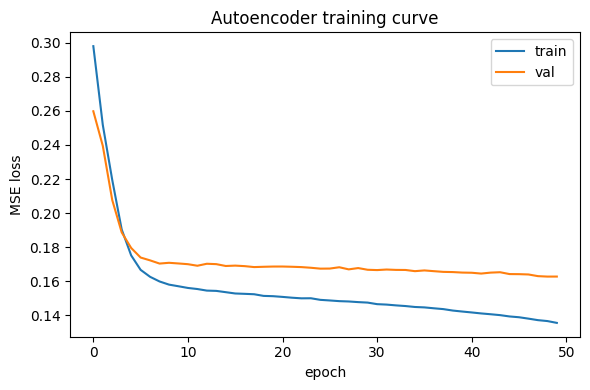

In [5]:
# Cell 5 — full training (fresh model, debug ladder above already mutated its weights)
model = MLPAutoencoder(INPUT_DIM)
model, history = train_autoencoder(model, train_vecs, val_vecs, device,
                                     epochs=50, batch_size=64, lr=1e-3, patience=5)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.title("Autoencoder training curve")
plt.tight_layout()
plt.savefig("figures/ae_training_curve.png", dpi=150)
plt.show()

os.makedirs("checkpoints", exist_ok=True)
torch.save(model.state_dict(), "checkpoints/ae_detector_n64.pt")

In [6]:
# Cell 6 — evaluate AE, compare to paper's Table 1 AE row and to our Step 3 PCA/Mahalanobis
paper_ae = {"tone": 0.7544, "chirp": 0.7816, "fawgn": 0.7615}  # BASE-PAPER FACT (Table 1)

ae_results = {}
for itype in ["tone", "chirp", "fawgn"]:
    samples, labels = build_test_set(cfg, N_SYMBOLS, rng, itype, 200, SIR_DB, SNR_DB)
    scores = [ae_score(x, model, device) for x in samples]
    auc = roc_auc_score(labels, scores)
    ae_results[itype] = auc
    print(f"{itype:6s}  AE AUC={auc:.4f}   paper AE AUC={paper_ae[itype]:.4f}")

import pandas as pd
comparison = pd.DataFrame({
    "paper_ae_auc": paper_ae,
    "our_ae_auc": ae_results,
})
comparison["difference"] = comparison["our_ae_auc"] - comparison["paper_ae_auc"]
print(comparison)
comparison.to_csv("results/ae_reproducibility_table.csv")

tone    AE AUC=0.5728   paper AE AUC=0.7544
chirp   AE AUC=0.5713   paper AE AUC=0.7816
fawgn   AE AUC=0.6001   paper AE AUC=0.7615
       paper_ae_auc  our_ae_auc  difference
tone         0.7544    0.572832   -0.181568
chirp        0.7816    0.571257   -0.210343
fawgn        0.7615    0.600060   -0.161440



=== compression=32 (bottleneck dim=32) ===
Epoch 1/50  train_loss=0.30159  val_loss=0.26133
Epoch 2/50  train_loss=0.25603  val_loss=0.24814
Epoch 3/50  train_loss=0.23477  val_loss=0.22792
Epoch 4/50  train_loss=0.21810  val_loss=0.22057
Epoch 5/50  train_loss=0.21227  val_loss=0.21849
Epoch 6/50  train_loss=0.20983  val_loss=0.21732
Epoch 7/50  train_loss=0.20801  val_loss=0.21700
Epoch 8/50  train_loss=0.20613  val_loss=0.21582
Epoch 9/50  train_loss=0.20458  val_loss=0.21516
Epoch 10/50  train_loss=0.20299  val_loss=0.21411
Epoch 11/50  train_loss=0.20154  val_loss=0.21356
Epoch 12/50  train_loss=0.19994  val_loss=0.21326
Epoch 13/50  train_loss=0.19856  val_loss=0.21285
Epoch 14/50  train_loss=0.19724  val_loss=0.21271
Epoch 15/50  train_loss=0.19618  val_loss=0.21173
Epoch 16/50  train_loss=0.19461  val_loss=0.21136
Epoch 17/50  train_loss=0.19315  val_loss=0.21009
Epoch 18/50  train_loss=0.19150  val_loss=0.20888
Epoch 19/50  train_loss=0.18960  val_loss=0.20807
Epoch 20/50  tr

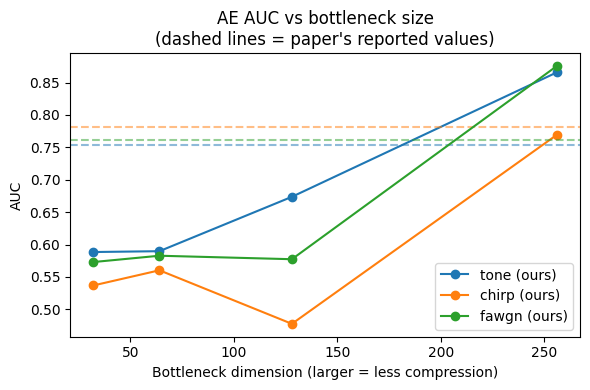

In [7]:
# Cell 7 — bottleneck compression sweep
compression_ratios = [32, 16, 8, 4]  # 32=most aggressive compression ... 4=least
sweep_rows = []

for comp in compression_ratios:
    bdim = max(8, INPUT_DIM // comp)
    print(f"\n=== compression={comp} (bottleneck dim={bdim}) ===")
    m = MLPAutoencoder(INPUT_DIM, compression=comp)
    m, hist = train_autoencoder(m, train_vecs, val_vecs, device,
                                  epochs=50, batch_size=64, lr=1e-3, patience=5)
    row = {"compression": comp, "bottleneck_dim": bdim, "final_val_loss": hist["val_loss"][-1]}
    for itype in ["tone", "chirp", "fawgn"]:
        samples, labels = build_test_set(cfg, N_SYMBOLS, rng, itype, 200, SIR_DB, SNR_DB)
        scores = [ae_score(x, m, device) for x in samples]
        row[f"{itype}_auc"] = roc_auc_score(labels, scores)
    sweep_rows.append(row)
    print(row)

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv("results/ae_bottleneck_sweep.csv", index=False)

plt.figure(figsize=(6,4))
colors = {"tone": "tab:blue", "chirp": "tab:orange", "fawgn": "tab:green"}
for itype, paper_val in paper_ae.items():
    plt.plot(sweep_df["bottleneck_dim"], sweep_df[f"{itype}_auc"], marker='o',
              label=f"{itype} (ours)", color=colors[itype])
    plt.axhline(paper_val, linestyle='--', alpha=0.5, color=colors[itype])
plt.xlabel("Bottleneck dimension (larger = less compression)")
plt.ylabel("AUC")
plt.title("AE AUC vs bottleneck size\n(dashed lines = paper's reported values)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/ae_bottleneck_sweep.png", dpi=150)
plt.show()

In [8]:
# Cell 8 — canonical, seeded final run at the best bottleneck size (compression=4)
model_final = MLPAutoencoder(INPUT_DIM, compression=4)
model_final, hist_final = train_autoencoder(model_final, train_vecs, val_vecs, device,
                                              epochs=50, batch_size=64, lr=1e-3, patience=5, seed=42)

final_results = {}
for itype in ["tone", "chirp", "fawgn"]:
    samples, labels = build_test_set(cfg, N_SYMBOLS, rng, itype, 200, SIR_DB, SNR_DB)
    scores = [ae_score(x, model_final, device) for x in samples]
    final_results[itype] = roc_auc_score(labels, scores)

final_comparison = pd.DataFrame({"paper_ae_auc": paper_ae, "our_ae_auc_final": final_results})
final_comparison["difference"] = final_comparison["our_ae_auc_final"] - final_comparison["paper_ae_auc"]
print(final_comparison)
final_comparison.to_csv("results/ae_final_seeded_comparison.csv")

torch.save(model_final.state_dict(), "checkpoints/ae_detector_n64_compression4_seeded.pt")

Epoch 1/50  train_loss=0.29586  val_loss=0.26016
Epoch 2/50  train_loss=0.25156  val_loss=0.23826
Epoch 3/50  train_loss=0.21378  val_loss=0.19499
Epoch 4/50  train_loss=0.17198  val_loss=0.16635
Epoch 5/50  train_loss=0.14413  val_loss=0.14524
Epoch 6/50  train_loss=0.12609  val_loss=0.13176
Epoch 7/50  train_loss=0.11014  val_loss=0.11793
Epoch 8/50  train_loss=0.10013  val_loss=0.10815
Epoch 9/50  train_loss=0.08920  val_loss=0.09877
Epoch 10/50  train_loss=0.08143  val_loss=0.09333
Epoch 11/50  train_loss=0.07498  val_loss=0.08716
Epoch 12/50  train_loss=0.06918  val_loss=0.07985
Epoch 13/50  train_loss=0.06332  val_loss=0.07350
Epoch 14/50  train_loss=0.05901  val_loss=0.06938
Epoch 15/50  train_loss=0.05404  val_loss=0.06347
Epoch 16/50  train_loss=0.05031  val_loss=0.05863
Epoch 17/50  train_loss=0.04540  val_loss=0.05477
Epoch 18/50  train_loss=0.04260  val_loss=0.04996
Epoch 19/50  train_loss=0.03900  val_loss=0.04751
Epoch 20/50  train_loss=0.03673  val_loss=0.04554
Epoch 21/

In [9]:
!git add checkpoints/ results/ figures/ notebooks/04_autoencoder_detector.ipynb src/
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   checkpoints/ae_detector_n64.pt
	modified:   figures/ae_training_curve.png
	modified:   results/ae_reproducibility_table.csv



In [10]:
!ls -la results/ figures/ checkpoints/

checkpoints/:
total 4768
drwxr-xr-x 2 root root    4096 Aug 29 06:05 .
drwxr-xr-x 8 root root    4096 Aug 29 06:05 ..
-rw-r--r-- 1 root root 2632917 Aug 29 06:07 ae_detector_n64_compression4_seeded.pt
-rw-r--r-- 1 root root 2238525 Aug 29 06:07 ae_detector_n64.pt
-rw-r--r-- 1 root root       0 Aug 29 06:05 .gitkeep

figures/:
total 780
drwxr-xr-x 2 root root   4096 Aug 29 06:05 .
drwxr-xr-x 8 root root   4096 Aug 29 06:05 ..
-rw-r--r-- 1 root root  77922 Aug 29 06:07 ae_bottleneck_sweep.png
-rw-r--r-- 1 root root  44159 Aug 29 06:07 ae_training_curve.png
-rw-r--r-- 1 root root 606669 Aug 29 06:05 fig1_reproduction.png
-rw-r--r-- 1 root root      0 Aug 29 06:05 .gitkeep
-rw-r--r-- 1 root root  50956 Aug 29 06:05 tone_freq_diagnostic.png

results/:
total 32
drwxr-xr-x 2 root root 4096 Aug 29 06:05 .
drwxr-xr-x 8 root root 4096 Aug 29 06:05 ..
-rw-r--r-- 1 root root  402 Aug 29 06:07 ae_bottleneck_sweep.csv
-rw-r--r-- 1 root root  187 Aug 29 06:07 ae_final_seeded_comparison.csv
-rw-r--r--

In [11]:
files_to_check = [
    "checkpoints/ae_detector_n64_compression4_seeded.pt",
    "results/ae_bottleneck_sweep.csv",
    "results/ae_final_seeded_comparison.csv",
    "figures/ae_bottleneck_sweep.png",
    "results/step3_findings.md",
    "results/step4_findings.md",
]
for f in files_to_check:
    print(f"--- {f} ---")
    !git check-ignore -v {f}
    !git log --oneline -1 -- {f}
    print()

--- checkpoints/ae_detector_n64_compression4_seeded.pt ---
e918d13 (HEAD -> main, origin/main, origin/HEAD) Step 4: fix .gitignore for checkpoints, add trained model + full notebook run

--- results/ae_bottleneck_sweep.csv ---
e918d13 (HEAD -> main, origin/main, origin/HEAD) Step 4: fix .gitignore for checkpoints, add trained model + full notebook run

--- results/ae_final_seeded_comparison.csv ---
e918d13 (HEAD -> main, origin/main, origin/HEAD) Step 4: fix .gitignore for checkpoints, add trained model + full notebook run

--- figures/ae_bottleneck_sweep.png ---
e918d13 (HEAD -> main, origin/main, origin/HEAD) Step 4: fix .gitignore for checkpoints, add trained model + full notebook run

--- results/step3_findings.md ---
8a40e0e Step 3: document frequency-dependent Mahalanobis blind spot finding

--- results/step4_findings.md ---
d6c8be7 Step 4: document findings (torch seeding bug, bottleneck sensitivity, final results)



In [12]:
!git add checkpoints/ae_detector_n64.pt figures/ae_training_curve.png results/ae_reproducibility_table.csv
!git commit -m "Step 4: update original (pre-seed-fix) AE run outputs for consistency"
!git push

[main cbefc55] Step 4: update original (pre-seed-fix) AE run outputs for consistency
 3 files changed, 3 insertions(+), 3 deletions(-)
 rewrite checkpoints/ae_detector_n64.pt (75%)
 rewrite figures/ae_training_curve.png (99%)
Enumerating objects: 15, done.
Counting objects: 100% (15/15), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 2.02 MiB | 4.69 MiB/s, done.
Total 8 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   e918d13..cbefc55  main -> main
